# L14 Multi-Demensional Gradient Descent & Feature Engineering

- Multi-Demensional Gradient Descent
	
	- Stochastic Gradient Descent
	
    	- Batch
    	
		- Mini-batch

- Feature Engineering

  - Feature Funcs
  
  - One-Hot Encoding
  
  - Polynomial Features
  
  - Complexity & Overfitting

## 1 Multi-Demensional Gradient Descent

A multiple linear regression has $p+1$ parameters $\theta$:

$$\mathbb{Y} = \theta_0 + \theta_1 \mathbb{X}_{:,1} + \theta_2 \mathbb{X}_{:,2} + \cdots + \theta_p \mathbb{X}_{:,p}$$

- It is a **loss surface** about $\theta$ s rather than a loss func of $\theta$

In [1]:
import seaborn as sns
import numpy as np
df = sns.load_dataset("tips")

In [2]:
import plotly.graph_objects as go


def mse_loss(theta, X, y_obs):
    y_hat = X @ theta
    return np.mean((y_hat - y_obs) ** 2)    

tips_with_bias = df.copy()
tips_with_bias["bias"] = 1
tips_with_bias = tips_with_bias[["bias", "total_bill"]]

uvalues = np.linspace(0, 2, 10)
vvalues = np.linspace(-0.1, 0.35, 10)
(u,v) = np.meshgrid(uvalues, vvalues)
thetas = np.vstack((u.flatten(),v.flatten()))

def mse_loss_single_arg(theta):
    return mse_loss(theta, tips_with_bias, df["tip"])

MSE = np.array([mse_loss_single_arg(t) for t in thetas.T])

loss_surface = go.Surface(x=u, y=v, z=np.reshape(MSE, u.shape))

ind = np.argmin(MSE)
optimal_point = go.Scatter3d(name = "Optimal Point",
    x = [thetas.T[ind,0]], y = [thetas.T[ind,1]], 
    z = [MSE[ind]],
    marker=dict(size=10, color="red"))

fig = go.Figure(data=[loss_surface, optimal_point])
fig.update_layout(scene = dict(
    xaxis_title = "theta0",
    yaxis_title = "theta1",
    zaxis_title = "MSE"), autosize=False, width=800, height=600)

fig.show()

- We can also visualize a bird’s-eye view of the loss surface from above using a contour plot

In [3]:
contour = go.Contour(x=u[0], y=v[:, 0], z=np.reshape(MSE, u.shape))
fig = go.Figure(contour)
fig.update_layout(
    xaxis_title = "theta0",
    yaxis_title = "theta1", autosize=False, width=800, height=600)

fig.show()

### The Gradient Vector

- In one dimension, we use derivatives

- In multi-demension, we use partial derivatives to form a **gradient vector**

$$\nabla_{\vec{\theta}} L =
\begin{bmatrix}
\frac{\partial L}{\partial \theta_0} \\
\frac{\partial L}{\partial \theta_1} \\
\vdots \\
\frac{\partial L}{\partial \theta_p}
\end{bmatrix}$$

- $\theta_0$ does not give directional info, so we take it out

- Let $L(\theta_1, \theta_2, ..., \theta_n)$ be the loss func, its **gradient (梯度)** is:

$$\nabla L =
\left(
\frac{\partial L}{\partial \theta_1},
\frac{\partial L}{\partial \theta_2},
\ldots,
\frac{\partial L}{\partial \theta_n}
\right)$$

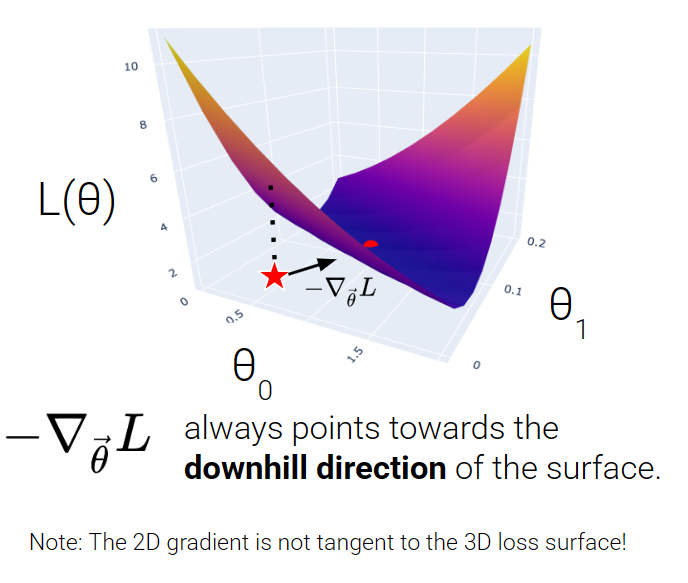
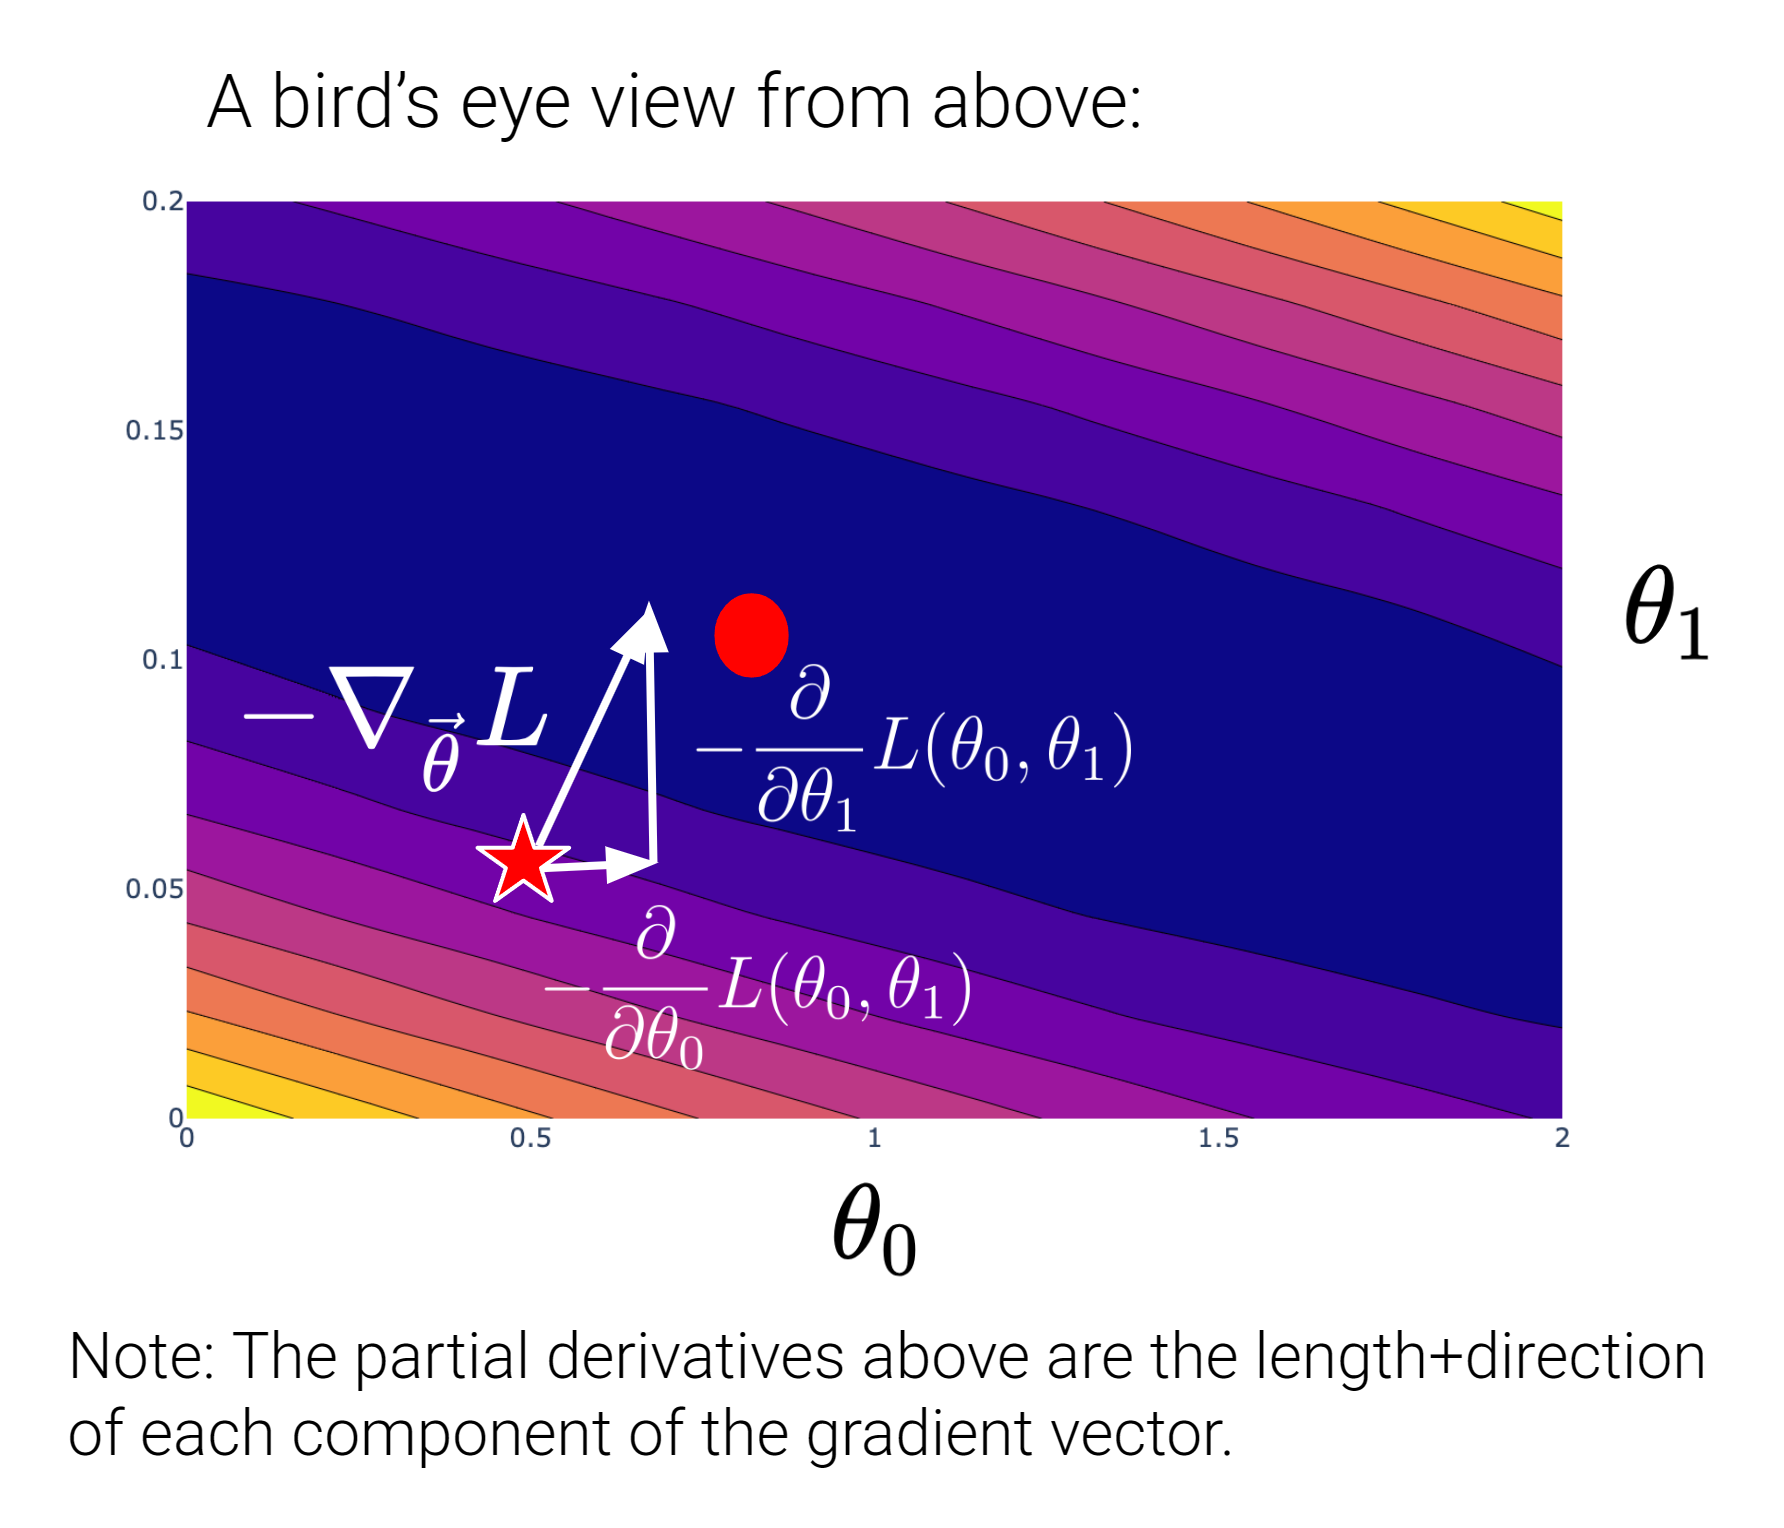

### Stochastic (Batch) Gradient Descent

### Stochastic (Mini-batch) Gradient Descent

- For each iteration of the algorithm, the derivative of loss $\nabla_{\vec{\theta}} L$ is computed **across the entire batch of all $n$ datapoints**

$$
\nabla_{\vec{\theta}} L\left(\vec{\theta}^{(t)}\right)=\frac{1}{n}\sum_{i=1}^{n}\nabla_{\vec{\theta}} l\left(y_i, f_{\vec{\theta}^{(t)}}(X_i)\right)
$$

$$
\vec{\theta}^{(t+1)}
=
\vec{\theta}^{(t)}
-
\alpha \nabla_{\vec{\theta}} L\left(\vec{\theta}^{(t)}\right)
$$

$$
\begin{bmatrix}
\theta_0^{(t+1)} \\
\theta_1^{(t+1)} \\
\vdots
\end{bmatrix}
=
\begin{bmatrix}
\theta_0^{(t)} \\
\theta_1^{(t)} \\
\vdots
\end{bmatrix}
-
\alpha
\begin{bmatrix}
\frac{\partial L}{\partial \theta_0} \\
\frac{\partial L}{\partial \theta_1} \\
\vdots
\end{bmatrix}
$$

- Though it is theoratically optimal, but for large datasets, finding the gradient across all the data is incredibly computationally taxing

### Stochastic (Mini-batch) Gradient Descent

- to speed it up, we use **a sample of the full dataset** at each update

- The **batch size** is the number of data points used in each sample

- Usually without replacement (data is shuffled and batch size examples are selected one at a time)

- Each complete “pass” through the data is known as a **training epoch**. After shuffling the data, in a single training epoch of stochastic gradient descent

<div style="background-color:#9ca3af30; padding:12px 16px; border-left:5px solid #9ca3af; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Note:</strong> **e.g.**

Say we have 10 samples $[1,2,3,4,5,6,7,8,9,10]$

1. Shuffle with **batch size = 2**

$$[7,2,9,1,5,10,3,8,6,4]$$

For this **one epoch**:

$$B_1=[7,2]$$

$$B_2=[9,1]$$

$$B_3=[5,10]$$

$$B_4=[3,8]$$

$$B_5=[6,4]$$

Next epoch:

$$[3,9,4,7,1,6,10,2,5,8]$$

And we do it again for epoch 2 here...

</div>

- Since we need to suffle here, we introduce randomness here

- Batch gradient descent is a **deterministic** technique while stochastic gradient descent is not

- SGD may not descend towards the true minimum with each update, but over the longer term, these **stochastic techniques should still converge towards the optimal solution**

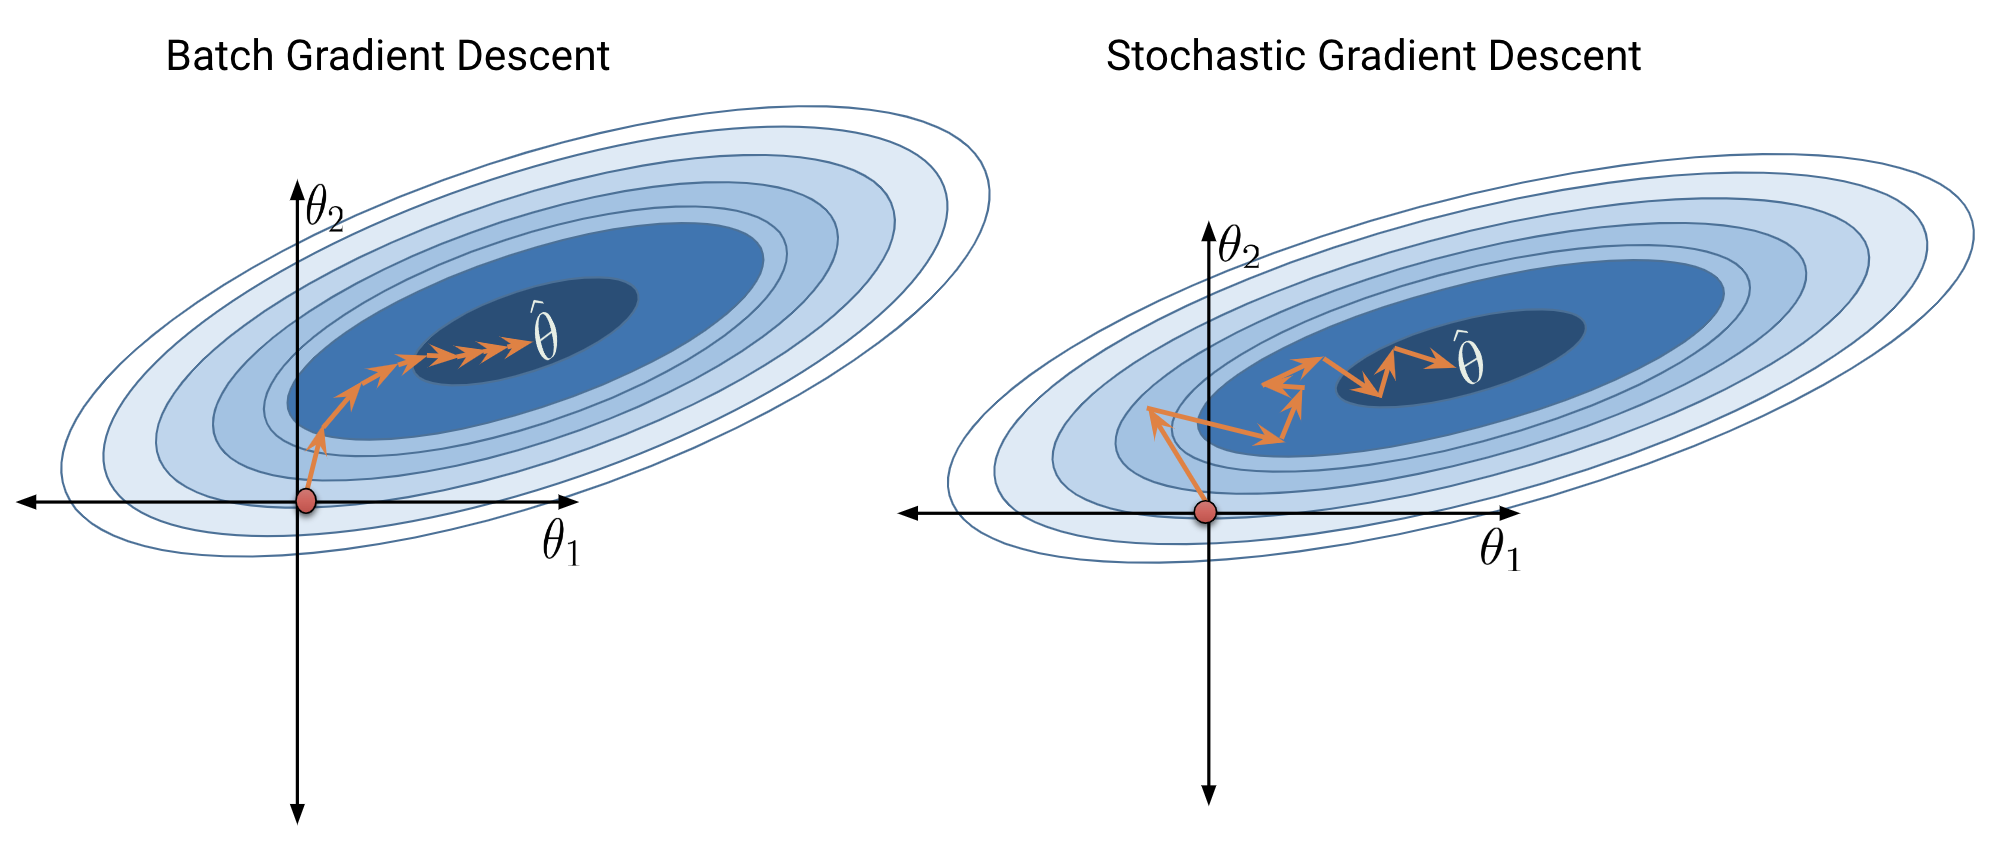

## 2 Feature Engineering

**Motivations**

- We are trying to linearize a dataset to fit the linear regression model

- This entails an assumption: **our predictions should be some combination of linear variables**, which is not always the case

### Feature Functions

- A **feature function (特征函数)** describes the transformations we apply to raw features in a dataset to create a design matrix of transformed features (typically denoted as $\Phi$)

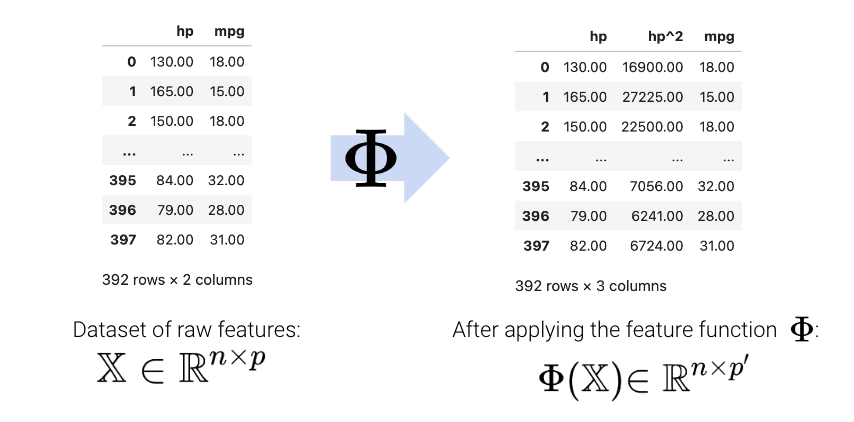

- The new features are denoted as $\phi$

- You will notice the numbers of features can be not the same $p$ & $p^\prime{}$

- If it is a linear transformation (Matrix), it can be $\Phi X$

### One-Hot Encoding

- Sometimes we want to run regression on non-numeric features

- We need to turn them into numbers

- **One-hot encoding** is a feature engineering technique that generates numeric features from categorical data

In [4]:
import numpy as np
import seaborn as sns
import pandas as pd
import sklearn.linear_model as lm
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


- We create a new table with a feature for each unique value in the original "day" column. We then iterate through the "day" column
  
- For each entry in "day" we fill the corresponding feature in the new table with 1. All other features are set to 0

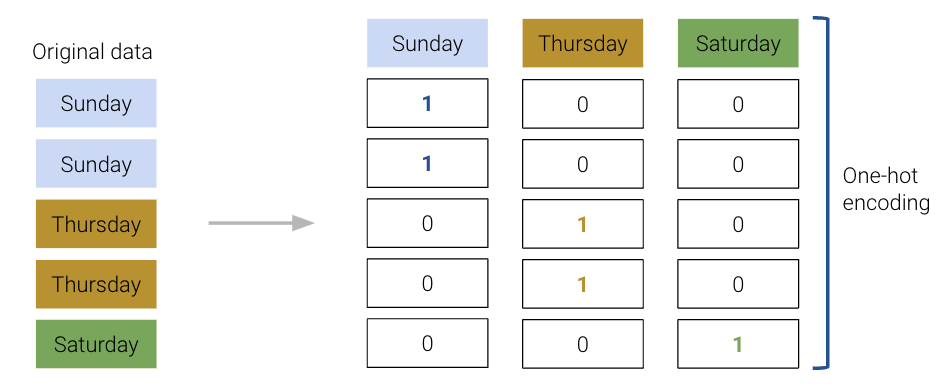

- Value = 1 if a row belongs to the category

- Value = 0 otherwise

The process is very similar to modeling process

In [5]:
from sklearn.preprocessing import OneHotEncoder

# Initialize a OneHotEncoder object
ohe = OneHotEncoder()

# Fit the encoder
ohe.fit(tips[["day"]])

# Use the encoder to transform the raw "day" feature
encoded_day = ohe.transform(tips[["day"]]).toarray()
encoded_day_df = pd.DataFrame(encoded_day, columns=ohe.get_feature_names_out())

encoded_day_df.head()

,day_Fri,day_Sat,day_Sun,day_Thur
0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0


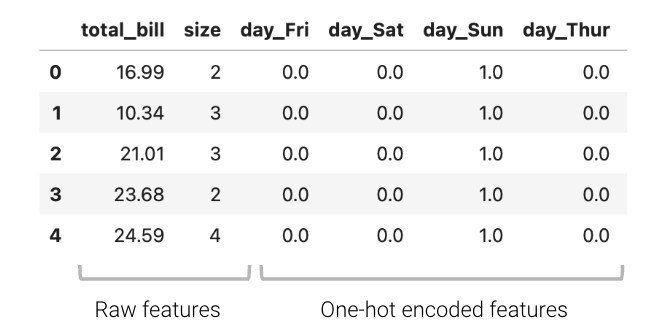

In [6]:
from sklearn.linear_model import LinearRegression
data_w_ohe = tips[["total_bill", "size", "day"]].join(encoded_day_df).drop(columns = "day")
ohe_model = lm.LinearRegression(fit_intercept=False) #Tell sklearn to not add an additional bias column. Why?
ohe_model.fit(data_w_ohe, tips["tip"])

pd.DataFrame({"Feature":data_w_ohe.columns, "Model Coefficient":ohe_model.coef_})

,Feature,Model Coefficient
0,total_bill,0.092994
1,size,0.187132
2,day_Fri,0.745787
3,day_Sat,0.621129
4,day_Sun,0.732289
5,day_Thur,0.668294


- Any set of one-hot encoded columns will always **sum to a column of all ones**, representing the bias column. More formally, the bias column is a linear combination of the OHE columns

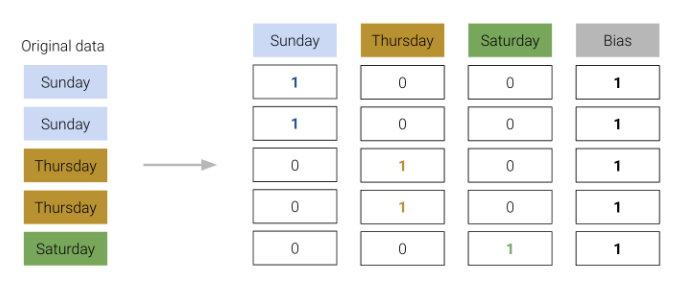

- We must be careful not to include this bias column in our design matrix. Otherwise, there will be **linear dependence** in the model

- To resolve this issue, we simply omit one of the one-hot encoded columns or do not include an intercept term

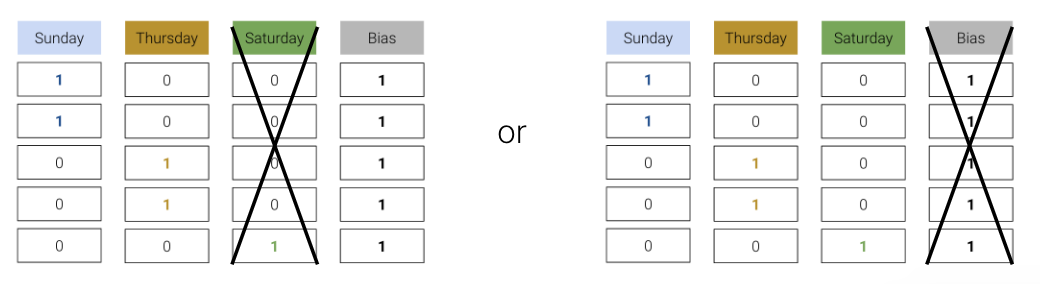

### Polynomial Features

- Sometimes we want to approximate **non-linear curvature**

- We can do this by **adding non-linear terms**

MSE of model with (hp) feature: 23.943662938603104


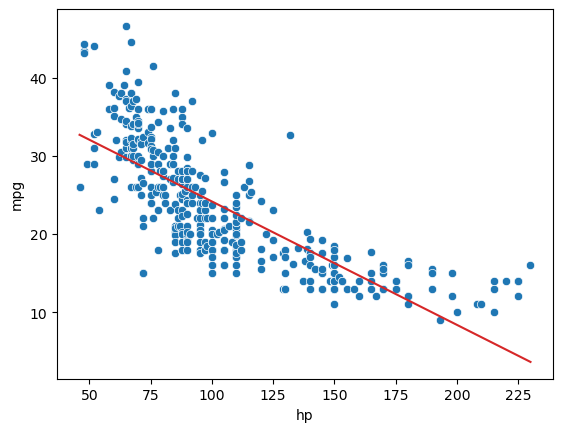

In [7]:
pd.options.mode.chained_assignment = None 
vehicles = sns.load_dataset("mpg").dropna().rename(columns = {"horsepower": "hp"}).sort_values("hp")

X = vehicles[["hp"]]
Y = vehicles["mpg"]

hp_model = lm.LinearRegression()
hp_model.fit(X, Y)
hp_model_predictions = hp_model.predict(X)

import matplotlib.pyplot as plt

sns.scatterplot(data=vehicles, x="hp", y="mpg")
plt.plot(vehicles["hp"], hp_model_predictions, c="tab:red");

print(f"MSE of model with (hp) feature: {np.mean((Y-hp_model_predictions)**2)}")

MSE of model with (hp^2) feature: 18.98476890761722


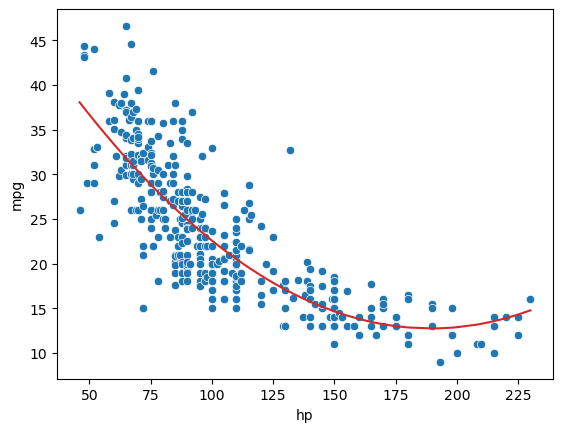

In [8]:
# Add a hp^2 feature to the design matrix
X = vehicles[["hp"]]
X["hp^2"] = vehicles["hp"]**2

# Use sklearn to fit the model
hp2_model = lm.LinearRegression()
hp2_model.fit(X, Y)
hp2_model_predictions = hp2_model.predict(X)

sns.scatterplot(data=vehicles, x="hp", y="mpg")
plt.plot(vehicles["hp"], hp2_model_predictions, c="tab:red");

print(f"MSE of model with (hp^2) feature: {np.mean((Y-hp2_model_predictions)**2)}")

- Can we add more higher-order terms?

	 - It may cause overfitting

### Complexity & Overfitting

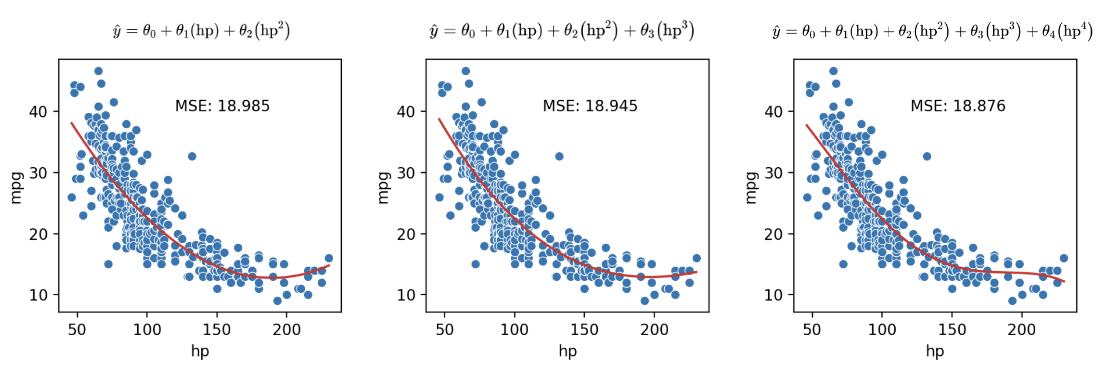

- MSE continues to **decrease with each additional polynomial term**

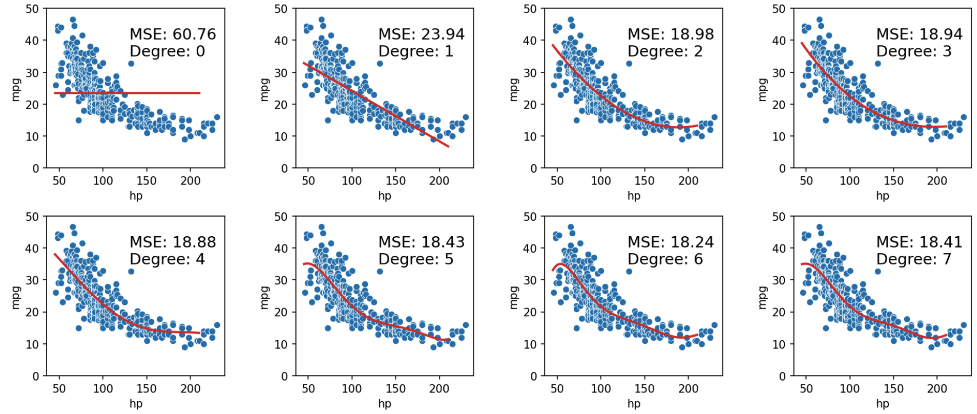

- The **training error** is the model’s error when generating predictions from the same data that was used for training purposes

- We can decrease training error by increasing model complexity

- But models that are too complex start to overfit and can’t be reapplied to new datasets due to **high variance**

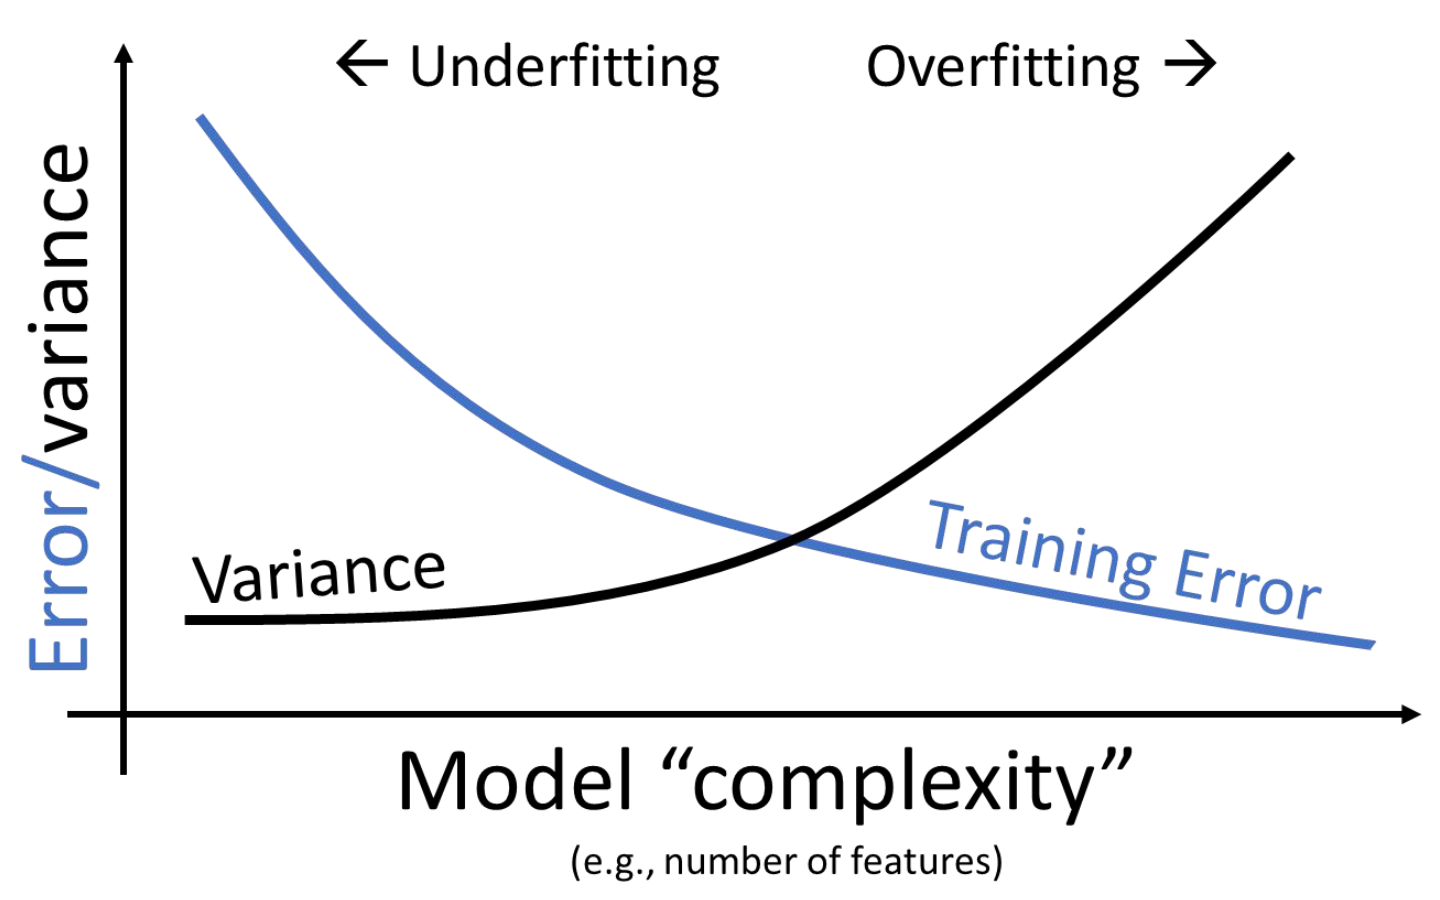

- How do we control the complexity of a model and choose the optimal degree? See Lec 15 on Cross-Validation and Regularization

---
[Reference](https://ds100.org/course-notes/feature-engineering/)